# Experiment v2: Unknown Category + Threshold Tuning

**목표**
- v2 전처리(Unknown category)로 XGBoost/LightGBM 재실험
- threshold tuning으로 F1 score 개선
- 기존 v1 baseline 점수와 비교

**참고 점수 (v1, 단일 split 기준)**
- XGBoost (tuned): 0.7138 / 0.9292 / 0.8215
- LightGBM: 0.7188 / 0.9288 / 0.8238

## 1. 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


train shape: (39073, 15)
test shape: (9769, 14)


## 2. v2 전처리 (Unknown Category)

민주님 v2 전처리와 동일한 로직.

In [2]:
cat_cols = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

# v2 핵심: mode 대신 "Unknown" 카테고리로 채우기
for col in cat_cols:
    train_df[col] = train_df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

# 타겟 인코딩
y_train = train_df["income"].map({"<=50K": 0, ">50K": 1})

# id 제거 + 인코딩
test_id = test_df["id"]
train_features = train_df.drop(columns=["income", "id"])
test_features = test_df.drop(columns=["id"])

full_df = pd.concat([train_features, test_features], axis=0)
full_encoded = pd.get_dummies(full_df, columns=cat_cols)

X_train = full_encoded.iloc[:len(train_df)]
X_test = full_encoded.iloc[len(train_df):]

print("X_train shape:", X_train.shape, "  (v1: 104 → v2: 107 예상)")
print("X_test shape:", X_test.shape)
print("y_train 분포:")
print(y_train.value_counts(normalize=True))


X_train shape: (39073, 107)   (v1: 104 → v2: 107 예상)
X_test shape: (9769, 107)
y_train 분포:
income
0    0.760858
1    0.239142
Name: proportion, dtype: float64


## 3. Train/Validation Split + 평가 함수

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(model, X_val, y_val, name="model"):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    score = (f1 + auc) / 2
    print(f"[{name}]  F1 = {f1:.4f}  AUC = {auc:.4f}  (F1+AUC)/2 = {score:.4f}")
    return {"name": name, "f1": f1, "auc": auc, "score": score}

print("train:", X_tr.shape, "  val:", X_val.shape)


train: (31258, 107)   val: (7815, 107)


## 4. Exp 2: v2 + XGBoost

In [4]:
from xgboost import XGBClassifier

xgb_v2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_v2.fit(X_tr, y_tr)
xgb_v2_result = evaluate(xgb_v2, X_val, y_val, name="XGBoost v2")


[XGBoost v2]  F1 = 0.7204  AUC = 0.9297  (F1+AUC)/2 = 0.8250


### 5-fold CV

In [5]:
xgb_v2_cv_f1 = cross_val_score(xgb_v2, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
xgb_v2_cv_auc = cross_val_score(xgb_v2, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost v2 5-fold CV F1 : {xgb_v2_cv_f1.mean():.4f}  (±{xgb_v2_cv_f1.std():.4f})")
print(f"XGBoost v2 5-fold CV AUC: {xgb_v2_cv_auc.mean():.4f}  (±{xgb_v2_cv_auc.std():.4f})")
print(f"XGBoost v2 5-fold CV (F1+AUC)/2: {(xgb_v2_cv_f1.mean() + xgb_v2_cv_auc.mean()) / 2:.4f}")


XGBoost v2 5-fold CV F1 : 0.7134  (±0.0019)
XGBoost v2 5-fold CV AUC: 0.9288  (±0.0036)
XGBoost v2 5-fold CV (F1+AUC)/2: 0.8211


## 5. Exp 3: v2 + LightGBM

In [6]:
from lightgbm import LGBMClassifier

lgbm_v2 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_v2.fit(X_tr, y_tr)
lgbm_v2_result = evaluate(lgbm_v2, X_val, y_val, name="LightGBM v2")


[LightGBM v2]  F1 = 0.7179  AUC = 0.9291  (F1+AUC)/2 = 0.8235


### 5-fold CV

In [7]:
lgbm_v2_cv_f1 = cross_val_score(lgbm_v2, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
lgbm_v2_cv_auc = cross_val_score(lgbm_v2, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"LightGBM v2 5-fold CV F1 : {lgbm_v2_cv_f1.mean():.4f}  (±{lgbm_v2_cv_f1.std():.4f})")
print(f"LightGBM v2 5-fold CV AUC: {lgbm_v2_cv_auc.mean():.4f}  (±{lgbm_v2_cv_auc.std():.4f})")
print(f"LightGBM v2 5-fold CV (F1+AUC)/2: {(lgbm_v2_cv_f1.mean() + lgbm_v2_cv_auc.mean()) / 2:.4f}")


LightGBM v2 5-fold CV F1 : 0.7121  (±0.0031)
LightGBM v2 5-fold CV AUC: 0.9286  (±0.0037)
LightGBM v2 5-fold CV (F1+AUC)/2: 0.8203


## 6. Exp 5: Threshold Tuning

**왜 하는가?**
- 기본 threshold는 0.5 (확률 ≥ 0.5면 1, 미만이면 0)
- 클래스 불균형(76:24) 때문에 0.5가 최적이 아닐 수 있음
- threshold를 낮추면 → 1 예측이 늘어남 → recall ↑, F1 변화
- AUC는 영향 받지 않음 (threshold 무관 지표). 하지만 F1은 크게 바뀔 수 있음

**전략**
- 0.05 ~ 0.95 사이를 0.01 단위로 훑으면서 F1이 최대가 되는 threshold 찾기
- best threshold로 다시 평가


In [8]:
# 두 모델 중 어느 게 더 잘 나왔는지 확인하고, 그 모델로 threshold tuning 진행
# 5-fold CV 평균이 더 신뢰성 있으므로 그걸로 비교
xgb_v2_cv_avg = (xgb_v2_cv_f1.mean() + xgb_v2_cv_auc.mean()) / 2
lgbm_v2_cv_avg = (lgbm_v2_cv_f1.mean() + lgbm_v2_cv_auc.mean()) / 2

print(f"XGBoost v2 CV 평균: {xgb_v2_cv_avg:.4f}")
print(f"LightGBM v2 CV 평균: {lgbm_v2_cv_avg:.4f}")

# 더 나은 모델 선택
if xgb_v2_cv_avg >= lgbm_v2_cv_avg:
    best_model = xgb_v2
    best_model_name = "XGBoost v2"
    print(f"\n→ Threshold tuning은 {best_model_name}로 진행")
else:
    best_model = lgbm_v2
    best_model_name = "LightGBM v2"
    print(f"\n→ Threshold tuning은 {best_model_name}로 진행")


XGBoost v2 CV 평균: 0.8211
LightGBM v2 CV 평균: 0.8203

→ Threshold tuning은 XGBoost v2로 진행


In [9]:
# Validation set에서 best threshold 찾기
y_val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"기본 threshold (0.5) F1: {f1_score(y_val, (y_val_prob >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.4f}")


기본 threshold (0.5) F1: 0.7204
Best threshold: 0.42
Best F1: 0.7342


### Threshold vs F1 시각화

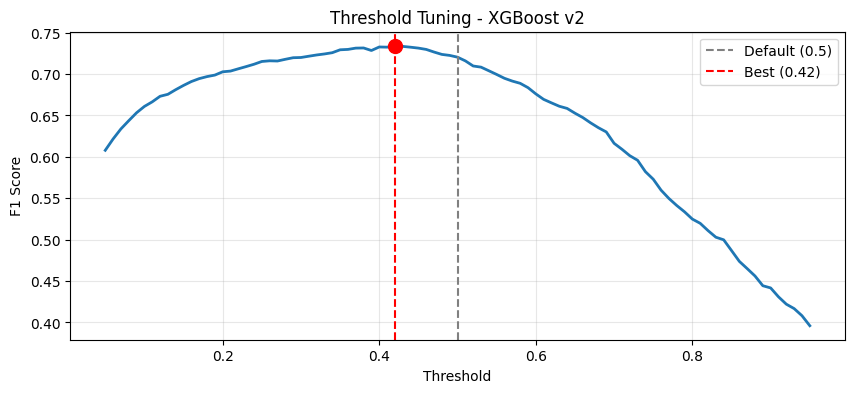

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best ({best_threshold:.2f})')
plt.scatter([best_threshold], [best_f1], color='red', s=100, zorder=5)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title(f'Threshold Tuning - {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Best threshold 적용 후 최종 점수

In [11]:
# Validation set에 best threshold 적용
y_val_pred_tuned = (y_val_prob >= best_threshold).astype(int)
f1_tuned = f1_score(y_val, y_val_pred_tuned)
auc_tuned = roc_auc_score(y_val, y_val_prob)  # AUC는 threshold 무관, 변화 없음
score_tuned = (f1_tuned + auc_tuned) / 2

print(f"[{best_model_name} + Threshold {best_threshold:.2f}]")
print(f"  F1 = {f1_tuned:.4f}")
print(f"  AUC = {auc_tuned:.4f}  (threshold 변경과 무관)")
print(f"  (F1+AUC)/2 = {score_tuned:.4f}")


[XGBoost v2 + Threshold 0.42]
  F1 = 0.7342
  AUC = 0.9297  (threshold 변경과 무관)
  (F1+AUC)/2 = 0.8319


## 7. 전체 실험 비교 표

In [12]:
results_df = pd.DataFrame([
    # v1 baseline (지난 결과)
    {"Exp": "v1 baseline", "Model": "Logistic Regression", "Threshold": 0.5, "F1": 0.6587, "AUC": 0.9063, "Avg": 0.7825},
    {"Exp": "v1 baseline", "Model": "Random Forest",       "Threshold": 0.5, "F1": 0.6599, "AUC": 0.8929, "Avg": 0.7764},
    {"Exp": "v1 baseline", "Model": "XGBoost (tuned)",     "Threshold": 0.5, "F1": 0.7138, "AUC": 0.9292, "Avg": 0.8215},
    {"Exp": "v1 baseline", "Model": "LightGBM",            "Threshold": 0.5, "F1": 0.7188, "AUC": 0.9288, "Avg": 0.8238},
    # v2 (이번 실험)
    {"Exp": "Exp 2 (v2)",  "Model": "XGBoost v2",  "Threshold": 0.5, "F1": xgb_v2_result['f1'],  "AUC": xgb_v2_result['auc'],  "Avg": xgb_v2_result['score']},
    {"Exp": "Exp 3 (v2)",  "Model": "LightGBM v2", "Threshold": 0.5, "F1": lgbm_v2_result['f1'], "AUC": lgbm_v2_result['auc'], "Avg": lgbm_v2_result['score']},
    # v2 + threshold tuning
    {"Exp": "Exp 5 (v2+th)","Model": best_model_name, "Threshold": round(best_threshold, 2), "F1": f1_tuned, "AUC": auc_tuned, "Avg": score_tuned},
])

print(results_df.to_string(index=False))


          Exp               Model  Threshold       F1      AUC      Avg
  v1 baseline Logistic Regression       0.50 0.658700 0.906300 0.782500
  v1 baseline       Random Forest       0.50 0.659900 0.892900 0.776400
  v1 baseline     XGBoost (tuned)       0.50 0.713800 0.929200 0.821500
  v1 baseline            LightGBM       0.50 0.718800 0.928800 0.823800
   Exp 2 (v2)          XGBoost v2       0.50 0.720366 0.929698 0.825032
   Exp 3 (v2)         LightGBM v2       0.50 0.717919 0.929083 0.823501
Exp 5 (v2+th)          XGBoost v2       0.42 0.734197 0.929698 0.831948


## 8. 최종 prediction.csv 생성 (v2 + threshold)

In [13]:
# 전체 train으로 best model 재학습 (validation set 포함)
if best_model_name == "XGBoost v2":
    final_model = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
    )
else:
    final_model = LGBMClassifier(
        n_estimators=200, learning_rate=0.05,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )

final_model.fit(X_train, y_train)

# Test set 예측
y_test_prob = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

prediction = pd.DataFrame({
    "id": test_id.values,
    "y_cls": y_test_pred,
    "y_prob": y_test_prob
})

prediction.to_csv("prediction.csv", index=False)

print(prediction.head())
print(f"\nprediction.csv saved, {len(prediction)} rows")
print(f"y_cls 분포: {prediction['y_cls'].value_counts().to_dict()}")


      id  y_cls    y_prob
0   7763      0  0.005014
1  23882      0  0.223754
2  30508      0  0.083432
3  28912      1  0.998115
4  19485      0  0.000471

prediction.csv saved, 9769 rows
y_cls 분포: {0: 7426, 1: 2343}
